# Part 4: Model Training and Evaluation
This notebook builds the machine learning models, benchmarks estimators, analyzes feature importances, and saves the production pipeline model.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, confusion_matrix, 
    classification_report, roc_auc_score,f1_score
)

df = pd.read_csv('../data/processed_telco_churn.csv')



# Train-Test Split 

In [3]:

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Logistic Regression Pipeline

In [4]:


lr_pipeline = Pipeline([
    ("scaler", RobustScaler()),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42,
    ))
])

param_grid = {
    "model__C": [0.01, 0.1, 1, 5, 10],
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"],
    "model__class_weight": [None, "balanced"]
}
# Stratified Cross Validation
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)


grid.fit(X_train, y_train)

print("Best Parameters:")
print(grid.best_params_)

best_lr = grid.best_estimator_

scores_lr = cross_validate(
    best_lr,
    X,
    y,
    cv=skf,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "roc_auc"
    ]
    ,n_jobs=-1
)

print("===== Logistic Regression =====")
print(f"Accuracy:       {np.mean(scores_lr['test_accuracy']):.4f} ± {np.std(scores_lr['test_accuracy']):.4f}")
print(f"Macro F1-Score: {np.mean(scores_lr['test_f1_macro']):.4f} ± {np.std(scores_lr['test_f1_macro']):.4f}")
print(f"ROC-AUC Score:  {np.mean(scores_lr['test_roc_auc']):.4f} ± {np.std(scores_lr['test_roc_auc']):.4f}")
print(f"Macro Precision:{np.mean(scores_lr['test_precision_macro']):.4f} ± {np.std(scores_lr['test_precision_macro']):.4f}")
print(f"Macro Recall:   {np.mean(scores_lr['test_recall_macro']):.4f} ± {np.std(scores_lr['test_recall_macro']):.4f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best Parameters:
{'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l1', 'model__solver': 'saga'}
===== Logistic Regression =====
Accuracy:       0.7525 ± 0.0069
Macro F1-Score: 0.7212 ± 0.0074
ROC-AUC Score:  0.8470 ± 0.0113
Macro Precision:0.7141 ± 0.0069
Macro Recall:   0.7634 ± 0.0091


# Cross Validation

In [5]:
cores_lr = cross_validate(
    best_lr,
    X,
    y,
    cv=skf,
    scoring=[
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "roc_auc"
    ]
    ,n_jobs=-1
)

print("===== Logistic Regression =====")
print(f"Accuracy:       {np.mean(scores_lr['test_accuracy']):.4f} ± {np.std(scores_lr['test_accuracy']):.4f}")
print(f"Macro F1-Score: {np.mean(scores_lr['test_f1_macro']):.4f} ± {np.std(scores_lr['test_f1_macro']):.4f}")
print(f"ROC-AUC Score:  {np.mean(scores_lr['test_roc_auc']):.4f} ± {np.std(scores_lr['test_roc_auc']):.4f}")
print(f"Macro Precision:{np.mean(scores_lr['test_precision_macro']):.4f} ± {np.std(scores_lr['test_precision_macro']):.4f}")
print(f"Macro Recall:   {np.mean(scores_lr['test_recall_macro']):.4f} ± {np.std(scores_lr['test_recall_macro']):.4f}")

===== Logistic Regression =====
Accuracy:       0.7525 ± 0.0069
Macro F1-Score: 0.7212 ± 0.0074
ROC-AUC Score:  0.8470 ± 0.0113
Macro Precision:0.7141 ± 0.0069
Macro Recall:   0.7634 ± 0.0091


# Logistic Regression Predict


In [6]:
best_lr.fit(X_train, y_train)
y_pred_lr = best_lr.predict(X_test)

c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\shubh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


# Logistic Regression Classification Report

In [7]:
print("===== Logistic Regression Classification Report =====")
print(classification_report(y_test, y_pred_lr))

===== Logistic Regression Classification Report =====
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



 # Baseline Model (Logistic Regression) Confusion Matrix

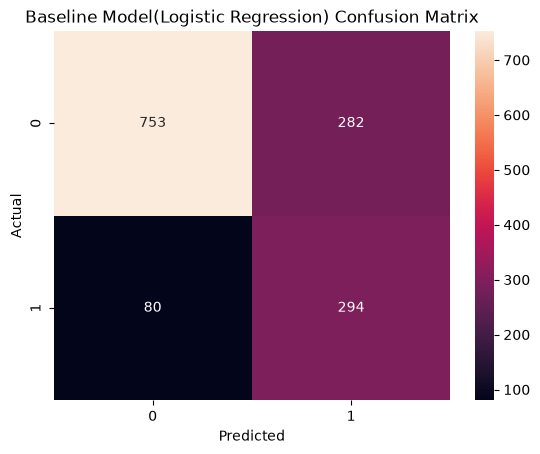

FileNotFoundError: [Errno 2] No such file or directory: 'plots/Model Evaluation/logistic regression confusion_matrix.png'

<Figure size 640x480 with 0 Axes>

In [8]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr,annot=True,fmt='d')
plt.title('Baseline Model(Logistic Regression) Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
plt.savefig(
    "plots/Model Evaluation/logistic regression confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)
plt.close()

 # Random Forest Pipeline

In [ ]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300, min_samples_split= 5, min_samples_leaf=4, max_features='log2',max_depth=10, bootstrap= True,class_weight='balanced',random_state=42
    ))
])

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores_rf = cross_validate(
    rf_pipeline,
    X,
    y,
    cv=skf,
    scoring=[
         "accuracy",
         "precision_macro",
         "recall_macro",
         "f1_macro",
         "roc_auc"
     ],
    n_jobs=-1
)

print("===== Random Forest =====")
print(f"Accuracy:       {np.mean(scores_rf['test_accuracy']):.4f} ± {np.std(scores_rf['test_accuracy']):.4f}")
print(f"Macro F1-Score: {np.mean(scores_rf['test_f1_macro']):.4f} ± {np.std(scores_rf['test_f1_macro']):.4f}")
print(f"ROC-AUC Score:  {np.mean(scores_rf['test_roc_auc']):.4f} ± {np.std(scores_rf['test_roc_auc']):.4f}")
print(f"Macro Precision:{np.mean(scores_rf['test_precision_macro']):.4f} ± {np.std(scores_rf['test_precision_macro']):.4f}")
print(f"Macro Recall:   {np.mean(scores_rf['test_recall_macro']):.4f} ± {np.std(scores_rf['test_recall_macro']):.4f}")

===== Random Forest =====
Accuracy:       0.7710 ± 0.0061
Macro F1-Score: 0.7282 ± 0.0080
ROC-AUC Score:  0.8364 ± 0.0119
Macro Precision:0.7179 ± 0.0074
Macro Recall:   0.7501 ± 0.0107


  # Random Forest Predict

In [ ]:
rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

# Random Forest Classification Report

In [ ]:
print("===== Random Forest Classification Report =====")

print(classification_report(y_test, y_pred_rf))

===== Random Forest Classification Report =====
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.54      0.70      0.61       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



# Random Forest Confusion Matrix

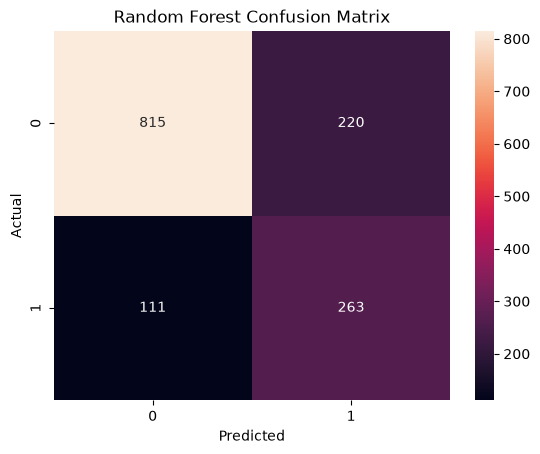

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf,annot=True,fmt='d')
plt.title('Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Save the Production Model

In [ ]:


joblib.dump(best_lr, 'customer_churn_model.pkl')
print("Production model successfully saved to 'customer_churn_model.pkl'")
df

Production model successfully saved to 'customer_churn_model.pkl'


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,14.925000,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,53.985714,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,36.050000,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,40.016304,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,50.550000,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,79.620000,1,1,1,1,0,1,0,0,0,1,0,0,0,1,0,1,0,1,0,1,1,0,1,0,0,1
7039,0,72,103.20,7362.90,0,100.861644,0,1,1,1,0,1,1,0,0,0,0,1,0,1,0,0,0,1,0,1,1,0,1,1,0,0
7040,0,11,29.60,346.45,0,28.870833,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
7041,1,4,74.40,306.60,1,61.320000,1,1,0,1,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1
